# 06 — Final Summary

Aggregates results from all experiments. No model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Cross-Experiment Results

In [2]:
final_summary = pd.DataFrame([
    {"Experiment": "Single-file Binary",         "Best Model": "Random Forest",  "Accuracy": 0.9998, "Precision": 0.9953, "Recall": 0.9883, "F1": 0.9918, "ROC_AUC": 1.0000},
    {"Experiment": "Multi-file Binary (all 8)",   "Best Model": "Random Forest",  "Accuracy": 0.9998, "Precision": 1.0000, "Recall": 0.9996, "F1": 0.9998, "ROC_AUC": 1.0000},
    {"Experiment": "Cross-file A: Web+DDoS→PortScan", "Best Model": "LR (by AUC)", "Accuracy": 0.5612, "Precision": 0.0416, "Recall": 0.0016, "F1": 0.0030, "ROC_AUC": 0.6995},
    {"Experiment": "Cross-file B: All→Infiltration",  "Best Model": "TBD",         "Accuracy": None,   "Precision": None,   "Recall": None,   "F1": None,   "ROC_AUC": None},
    {"Experiment": "Multiclass Web Attacks",      "Best Model": "Random Forest",  "Accuracy": 0.9952, "Precision": 0.79,   "Recall": 0.65,   "F1": 0.70,   "ROC_AUC": None},
])
final_summary

,Experiment,Best Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Single-file Binary,Random Forest,0.9998,0.9953,0.9883,0.9918,1.0000
1,Multi-file Binary (all 8),Random Forest,0.9998,1.0000,0.9996,0.9998,1.0000
2,Cross-file A: Web+DDoS→PortScan,LR (by AUC),0.5612,0.0416,0.0016,0.0030,0.6995
3,Cross-file B: All→Infiltration,TBD,NaN,NaN,NaN,NaN,NaN
4,Multiclass Web Attacks,Random Forest,0.9952,0.7900,0.6500,0.7000,NaN


## 2. F1-Score Chart

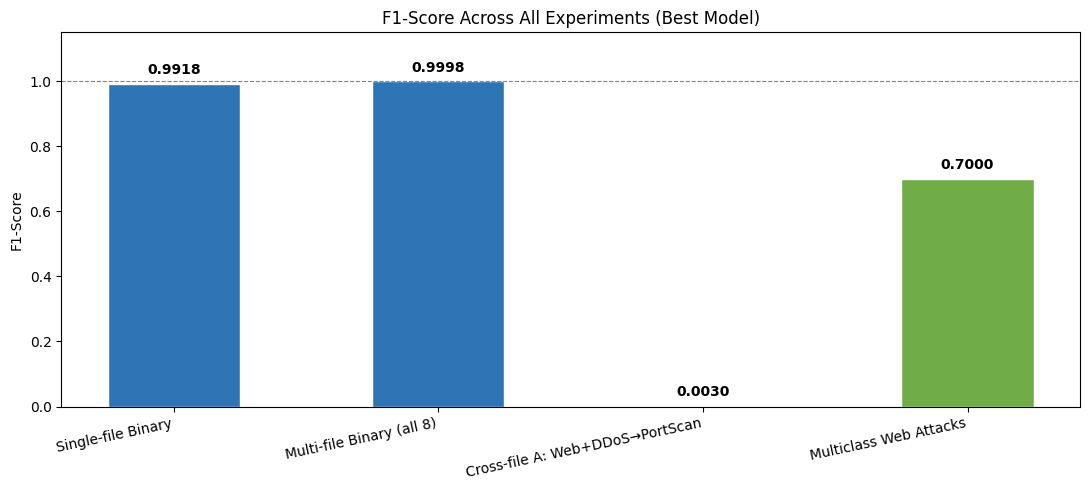

In [3]:
plot_df = final_summary.dropna(subset=["F1"])
colors  = ["#2E75B6", "#2E75B6", "#C00000", "#70AD47"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(plot_df["Experiment"], plot_df["F1"],
              color=colors[:len(plot_df)], edgecolor="white", width=0.5)
for bar, val in zip(bars, plot_df["F1"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_ylabel("F1-Score")
ax.set_title("F1-Score Across All Experiments (Best Model)")
ax.axhline(1.0, color="gray", linewidth=0.8, linestyle="--")
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

## 3. Single-File Model Comparison

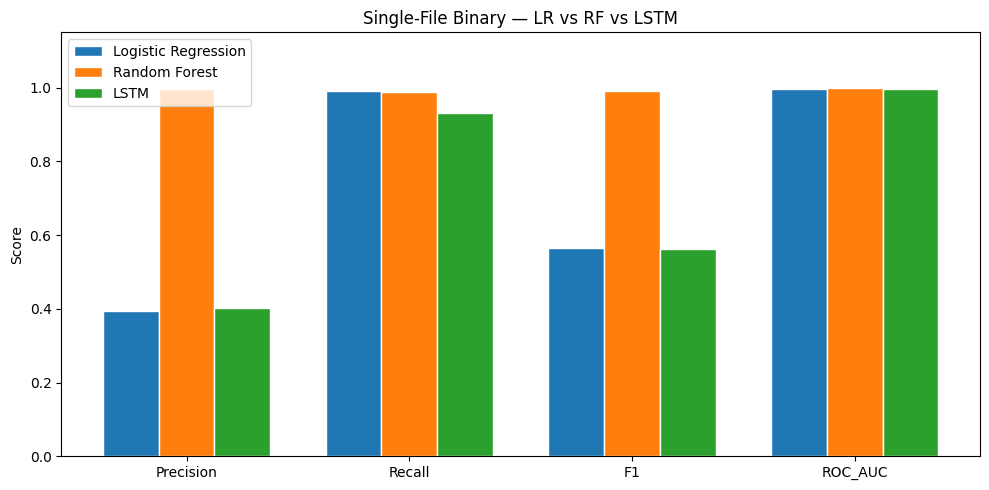

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,FP,FN
0,Logistic Regression,0.9800,0.3939,0.9907,0.5637,0.9973,654,4
1,Random Forest,0.9998,0.9953,0.9883,0.9918,1.0000,2,5
2,LSTM,0.9810,0.4018,0.9322,0.5616,0.9958,594,29


In [4]:
single_file_df = pd.DataFrame([
    {"Model": "Logistic Regression", "Accuracy": 0.9800, "Precision": 0.3939, "Recall": 0.9907, "F1": 0.5637, "ROC_AUC": 0.9973, "FP": 654, "FN": 4},
    {"Model": "Random Forest",       "Accuracy": 0.9998, "Precision": 0.9953, "Recall": 0.9883, "F1": 0.9918, "ROC_AUC": 1.0000, "FP": 2,   "FN": 5},
    {"Model": "LSTM",                "Accuracy": 0.9810, "Precision": 0.4018, "Recall": 0.9322, "F1": 0.5616, "ROC_AUC": 0.9958, "FP": 594, "FN": 29},
])

metrics = ["Precision", "Recall", "F1", "ROC_AUC"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(single_file_df.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metrics], width,
           label=row["Model"], edgecolor="white")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Single-File Binary — LR vs RF vs LSTM")
ax.legend()
plt.tight_layout()
plt.show()

single_file_df

## 4. Key Takeaways

**Random Forest** dominated all within-distribution experiments — near-perfect F1 with only 2 false positives in single-file testing.

**LSTM** matched Logistic Regression on ROC-AUC and showed sequential modeling is viable, but did not outperform Random Forest under the current sliding-window approach. Botnet and infiltration files are the strongest candidates for LSTM to show an advantage since those attacks are inherently sequential.

**Cross-file generalization** was the most important finding — all models collapsed when attack types changed between train and test (F1 < 0.003 on PortScan).

**Multiclass classification** showed macro F1 (0.70) is a far more honest metric than overall accuracy (0.9952) when minority classes like XSS and SQL Injection are present.

## 5. Limitations

- LSTM used simple sliding-window sequences, not true IP-session grouping
- LSTM architecture was minimal (1 layer, 64 units, 5 epochs)
- XGBoost was not implemented despite being proposed
- No attention weight visualization
- Cross-file Experiment B results pending (run notebook 04)
- One limitation is that the datasets are very large, so I used sampled rows from each file to keep the notebooks runnable on a local laptop. Because of this, the results should be viewed as a comparison rather than a final production-level intrusion detection system.
- Another limitation is that the models were tested on public benchmark datasets, not live network traffic. The results may look strong on random train-test splits, but real network environments can be more unpredictable. The cross-dataset comparison helped make the evaluation more realistic by testing performance across CICIDS2017 and CSE-CIC-IDS2018.

## Updated Results After Adding CSE-CIC-IDS2018

After the original CICIDS2017 experiments, I added CSE-CIC-IDS2018 as a newer intrusion detection dataset. This helped test whether the same models could still perform well on newer network traffic data. The comparison included a Dummy Classifier baseline, Logistic Regression, Decision Tree, and Random Forest.

The results showed that Random Forest generally performed the strongest, while the Dummy Classifier gave a basic baseline. The cross-dataset comparison was more realistic because it tested whether a model trained on one dataset could work on another dataset. This is important because high performance on one dataset does not always mean the model will generalize well to newer or different traffic patterns.